In [4]:
# Import the required packages for Exercise 1
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

AYEBIE GRAM MESCAHC EXERCISE 1

In [6]:
# Connect Google Drive to the notebook where the dataset is stored
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [7]:
# upload of the data
from google.colab import files
uploaded = files.upload()

Saving data.csv.data to data.csv.data


In [8]:
df = pd.read_csv("data.csv.data")

In [ ]:
# Display the first 5 rows of the dataset
df.head()

,vhigh,vhigh.1,2,2.1,small,low,unacc
0,vhigh,vhigh,2,2,small,med,unacc
1,vhigh,vhigh,2,2,small,high,unacc
2,vhigh,vhigh,2,2,med,low,unacc
3,vhigh,vhigh,2,2,med,med,unacc
4,vhigh,vhigh,2,2,med,high,unacc


In [9]:
# Show the shape of the dataset (number of rows and columns)
df.info()
df.shape

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1727 entries, 0 to 1726
Data columns (total 7 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   vhigh    1727 non-null   object
 1   vhigh.1  1727 non-null   object
 2   2        1727 non-null   object
 3   2.1      1727 non-null   object
 4   small    1727 non-null   object
 5   low      1727 non-null   object
 6   unacc    1727 non-null   object
dtypes: object(7)
memory usage: 94.6+ KB


(1727, 7)

We noticed that the dataset gives 1727 observations instead of 1728
because the first observation was used as column headers.
To fix this, we add and rename the columns manually so that we keep all observations.


In [10]:
#Rename the columns to meaningful names for better readability
# Original dataset had duplicate names like 'vhigh.1', '2.1', 'low.1'
# We assign descriptive names: buying, maint, doors, persons, lug_boot, safety, class

df = pd.read_csv("data.csv.data", header=None)
df.columns = ["buying", "maint", "doors", "persons", "lug_boot", "safety", "class"]
print(df.head())


  buying  maint doors persons lug_boot safety  class
0  vhigh  vhigh     2       2    small    low  unacc
1  vhigh  vhigh     2       2    small    med  unacc
2  vhigh  vhigh     2       2    small   high  unacc
3  vhigh  vhigh     2       2      med    low  unacc
4  vhigh  vhigh     2       2      med    med  unacc


In [11]:
df.head()

,buying,maint,doors,persons,lug_boot,safety,class
0,vhigh,vhigh,2,2,small,low,unacc
1,vhigh,vhigh,2,2,small,med,unacc
2,vhigh,vhigh,2,2,small,high,unacc
3,vhigh,vhigh,2,2,med,low,unacc
4,vhigh,vhigh,2,2,med,med,unacc


In [15]:
# Verify the columns 'maint' and 'buying' to check if they contain the same information

same=(df["buying"]==df["maint"]).all()
if same:
    print("they are ident")
    df=df.drop(columns=["maint"])
else:
    print("they aren't")

they aren't


In [12]:
df.shape

(1728, 7)

descriptive statistics for understanding data

In [13]:
# 2. Check for missing values
print("\nMissing values in each column:")
print(df.isnull().sum())

#This data dosen't have any missing value


Missing values in each column:
buying      0
maint       0
doors       0
persons     0
lug_boot    0
safety      0
class       0
dtype: int64


In [14]:
# List of columns and number of unique values
for col in df.columns:
    print(f"{col}: {df[col].nunique()} unique values → {df[col].unique()}")

# we observed the differents values for the features in the dataset


buying: 4 unique values → ['vhigh' 'high' 'med' 'low']
maint: 4 unique values → ['vhigh' 'high' 'med' 'low']
doors: 4 unique values → ['2' '3' '4' '5more']
persons: 3 unique values → ['2' '4' 'more']
lug_boot: 3 unique values → ['small' 'med' 'big']
safety: 3 unique values → ['low' 'med' 'high']
class: 4 unique values → ['unacc' 'acc' 'vgood' 'good']


In [ ]:
# Frequency count for each column
for col in df.columns:
    print(f"\nColumn: {col}")
    print(df[col].value_counts())



Column: buying
buying
vhigh    432
high     432
med      432
low      432
Name: count, dtype: int64

Column: maint
maint
vhigh    432
high     432
med      432
low      432
Name: count, dtype: int64

Column: doors
doors
2        432
3        432
4        432
5more    432
Name: count, dtype: int64

Column: persons
persons
2       576
4       576
more    576
Name: count, dtype: int64

Column: lug_boot
lug_boot
small    576
med      576
big      576
Name: count, dtype: int64

Column: safety
safety
low     576
med     576
high    576
Name: count, dtype: int64

Column: class
class
unacc    1210
acc       384
good       69
vgood      65
Name: count, dtype: int64


/tmp/ipython-input-1944639400.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x="class", order=df["class"].value_counts().index, palette="Set2")


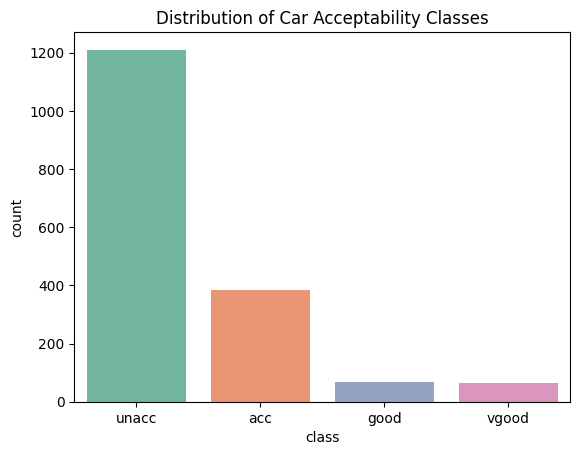

class
unacc    70.023148
acc      22.222222
good      3.993056
vgood     3.761574
Name: proportion, dtype: float64

Class distribution (counts):
class
unacc    1210
acc       384
good       69
vgood      65
Name: count, dtype: int64

Class distribution (percentages):
class
unacc    70.023148
acc      22.222222
good      3.993056
vgood     3.761574
Name: proportion, dtype: float64


In [ ]:

sns.countplot(data=df, x="class", order=df["class"].value_counts().index, palette="Set2")
plt.title("Distribution of Car Acceptability Classes")
plt.show()

print(df["class"].value_counts(normalize=True) * 100)

print("\nClass distribution (counts):")
print(df["class"].value_counts())
print("\nClass distribution (percentages):")
print(df["class"].value_counts(normalize=True) * 100)



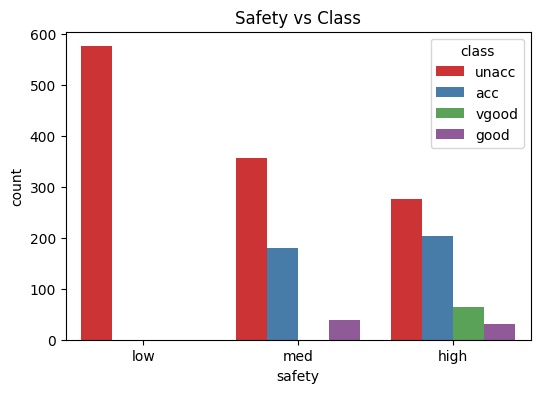

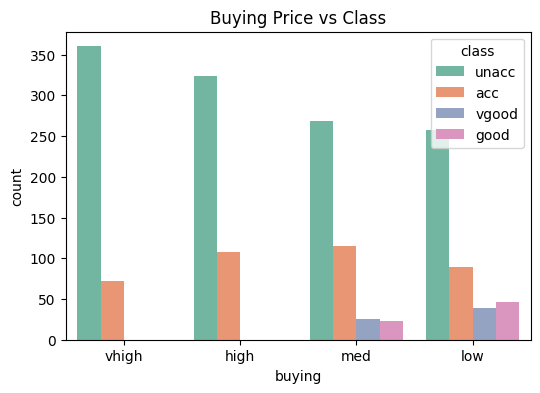

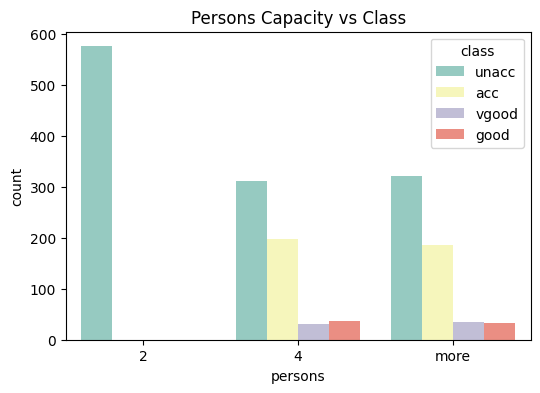

In [ ]:
# 6. Relationships between important features and target
plt.figure(figsize=(6,4))
sns.countplot(data=df, x="safety", hue="class", palette="Set1")
plt.title("Safety vs Class")
plt.show()

plt.figure(figsize=(6,4))
sns.countplot(data=df, x="buying", hue="class", palette="Set2")
plt.title("Buying Price vs Class")
plt.show()

plt.figure(figsize=(6,4))
sns.countplot(data=df, x="persons", hue="class", palette="Set3")
plt.title("Persons Capacity vs Class")
plt.show()

The overall accessibility rating (Class) of a car is determined by a complex interplay of its Safety, Persons Capacity, and Buying Price. Safety is an essential condition. If the safety level is low, the car will almost always be classified as unacceptable (unacc).Conversely, the very good (vgood) and good statuses are only significantly achieved when safety is high, However Persons Capacity is also crucial. Cars that can only accommodate 2 persons are overwhelmingly judged unacceptable. For a car to reach an acceptable (acc) status or better, it must be able to transport 4 persons or more. Also the Buying Price plays a less determinant role than safety or capacity, as the majority of cars across all price points are classified as unacceptable (unacc).However, to obtain a very good (vgood) or good class, the buying price should ideally be medium (med) or low. High or very high prices result in fewer cars achieving these top classifications.
To be more precise and simple for a car to be considered acceptable or better, it must have at least medium safety (ideally high) and a capacity of 4 persons or more. Having a moderate or low buying price then improves the chances of reaching the best classes (vgood/good).

In [ ]:
pd.crosstab(df["safety"], df["class"], normalize="index")


class,acc,good,unacc,vgood
safety,,,,
high,0.354167,0.052083,0.480903,0.112847
low,0.000000,0.000000,1.000000,0.000000
med,0.312500,0.067708,0.619792,0.000000


The normalized contingency table confirms that safety is the most reliable attribute for determining the overall accessibility class, acting as an elimination filter. This safety then becomes a necessary condition: without it, accessibility is zero. But even high safety alone is not enough, because almost half of the cars remain unacceptable (due to other factors such as capacity and price).

Before applying MCA, we explored the dataset to better understand its structure.
- The dataset contains 1728 rows and 7 columns (6 categorical features + 1 target variable).
- Each feature has a small number of categories, such as "buying" (vhigh, high, med, low) and "safety" (low, med, high).
- The target variable "class" is imbalanced: most cars are "unacc" (unacceptable), while "vgood" (very good) is rare.
- This imbalance will influence our analysis and must be kept in mind when interpreting results.


buying → prix d’achat (vhigh, high, med, low)

maint → coût de maintenance (vhigh, high, med, low)

doors → nombre de portes (2, 3, 4, 5more)

persons → capacité en passagers (2, 4, more)

lug_boot → taille du coffre (small, med, big)

safety → sécurité (low, med, high)

class → acceptabilité globale (unacc, acc, good, vgood)

I'll be using Multiple Correspondence Analysis (MCA) for this analysis because it's the most suitable dimensionality reduction method for my dataset, which is composed entirely of categorical variables.

The purpose of MCA is to transform these categories into numerical points on a graph, allowing me to visualize the relationships between them. Categories that are often associated will appear close to each other, while those that are rarely associated will be far apart.

By analyzing the first two components of the MCA, I aim to uncover the main trade-offs in car evaluation. The eigenvalues for these components will indicate how much of the total variance they explain, and their equal values suggest that the evaluation is not dominated by a single factor, but rather by a balanced set of compromises.

In [19]:
# Install the 'prince' package for Multiple Correspondence Analysis (MCA)
!pip install prince

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 178.9/178.9 kB 6.3 MB/s eta 0:00:00


In [20]:
# we want to Apply a dimensionality reduction method (MCA) on the Car Evaluation dataset
import prince

In [21]:
# question 1a

# Drop the target variable 'class' because MCA is applied only on the explanatory variables
X = df.drop("class", axis=1)

# Check the shape of the dataset
print("Shape of the dataset:", X.shape)


Shape of the dataset: (1728, 6)


In [22]:
# Apply MCA
mca = prince.MCA(n_components=3, random_state=42)
mca = mca.fit(X)

# Eigenvalues and explained inertia
eigvals = mca.eigenvalues_
print("Eigenvalues:", eigvals)
explained_var = eigvals / eigvals.sum()
print("Explained variance (manual):", explained_var)



Eigenvalues: [0.16666667 0.16666667 0.16666667]
Explained variance (manual): [0.33333333 0.33333333 0.33333333]


In [ ]:
mca

MCA(n_components=3, random_state=42)

**The eigenvalues are all equal (0.166), which means that the first three components
explain the same amount of variation. Each component explains 33% of the total inertia.
This shows that car evaluation is not dominated by a single factor,
but rather distributed across cost (buying and maintenance), safety and capacity,
and other practical aspects such as doors and luggage boot.**

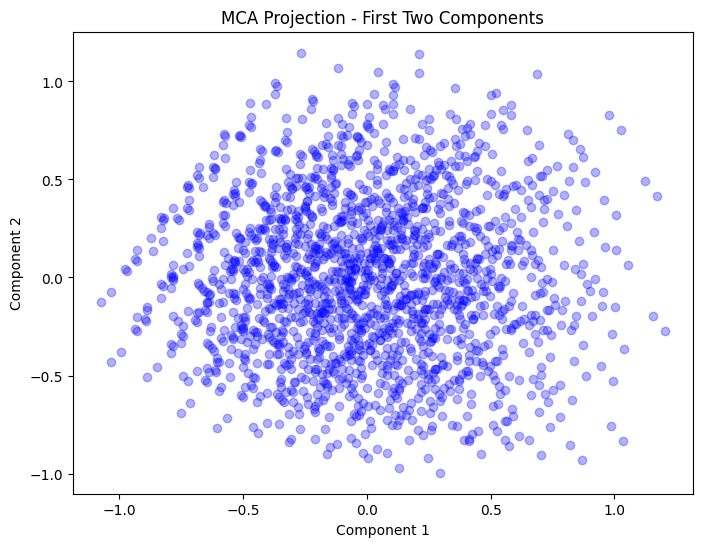

In [ ]:
# Plot the data on the first two MCA components
X_mca = mca.transform(X)

plt.figure(figsize=(8,6))
plt.scatter(X_mca[0], X_mca[1], alpha=0.3, c='blue')
plt.title("MCA Projection - First Two Components")
plt.xlabel("Component 1")
plt.ylabel("Component 2")
plt.show()

In [ ]:
mca.column_coordinates(X)  # Position of categories on components
mca.column_contributions_   # Contribution of each variable (si dispo)

,0,1,2
buying__high,0.038409,0.003341,0.085592
buying__low,0.025906,0.040246,0.000548
buying__med,0.083630,0.000076,0.020606
buying__vhigh,0.064598,0.022960,0.170314
maint__high,0.008906,0.004538,0.010533
maint__low,0.088471,0.002500,0.105560
maint__med,0.011332,0.001479,0.000565
maint__vhigh,0.081428,0.003115,0.039404
doors__2,0.001004,0.061020,0.038464
doors__3,0.044941,0.026417,0.077528


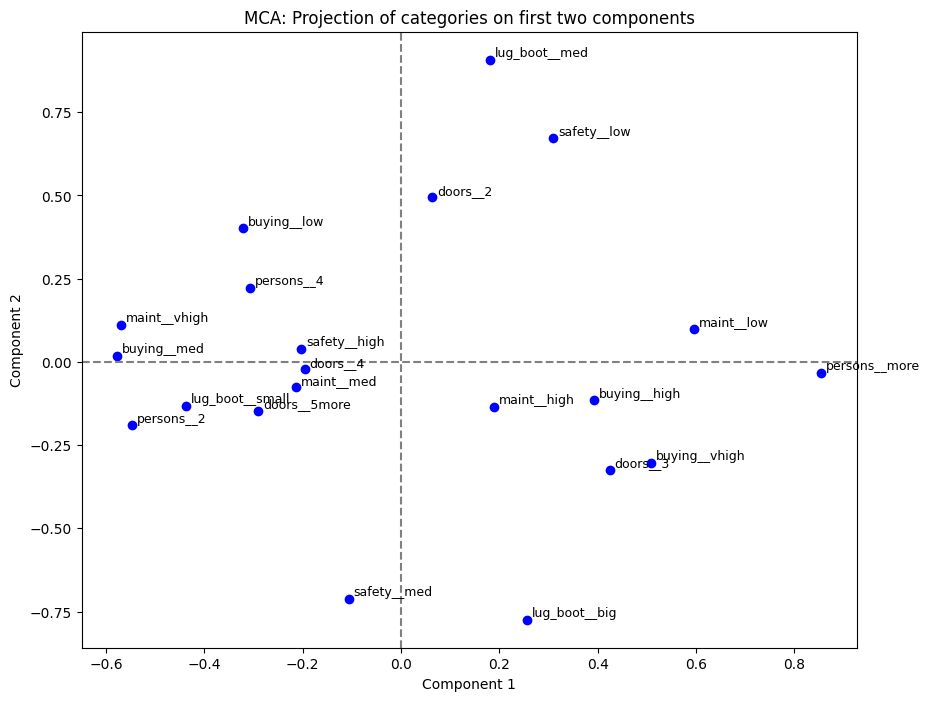

In [ ]:
# Get the coordinates of the categories on the MCA dimensions
coords = mca.column_coordinates(X)

plt.figure(figsize=(10, 8))

# Plot each category (modalities)
for i in range(coords.shape[0]):
    plt.scatter(coords.iloc[i, 0], coords.iloc[i, 1], color="blue")
    plt.text(coords.iloc[i, 0]+0.01, coords.iloc[i, 1]+0.01,
             coords.index[i], fontsize=9)

plt.axhline(0, color='grey', linestyle='--')
plt.axvline(0, color='grey', linestyle='--')
plt.xlabel("Component 1")
plt.ylabel("Component 2")
plt.title("MCA: Projection of categories on first two components")
plt.show()


The factorial plane (Component 1 and Component 2) captures 66.66% of the total inertia and reveals the underlying structure of the variables.
Axis 1, the Cost and Capacity factor (33.33% of the inertia), is the main differentiator. It clearly opposes the high-status/high-capacity modalities (right side: persons_more, buying_vhigh, maint_high) with the economy/compact modalities (left side: persons_2, buying_low, maint_med). This axis therefore segments the dataset based on the car's size and price. Similarly, Axis 2 (Vertical), which accounts for the Safety and Risk factor, is crucial because it isolates the risk factor. It is dominated by the safety_low modality in its upper part (Positive Pole), separating it from the safety_med and lug_boot_big modalities in its lower part. The proximity of points demonstrates strong associations, notably the association of high cost and high capacity (persons_more is statistically linked to buying_vhigh) and the isolation of safety_low on Axis 2, which confirms that low safety is a dimension of variation independent of the price and capacity scales. Overall, Multiple Correspondence Analysis (MCA) decomposes the variation in your data into two main dimensions: cost/size (Axis 1) and safety/risk (Axis 2). The structure shows that to predict global accessibility, the model must consider these two factors: the car's Status and the intrinsic Risk it represents.The fact that safety_low is isolated on its own axis confirms the critical role of this criterion as an eliminator of acceptability



<Axes: xlabel='0', ylabel='1'>

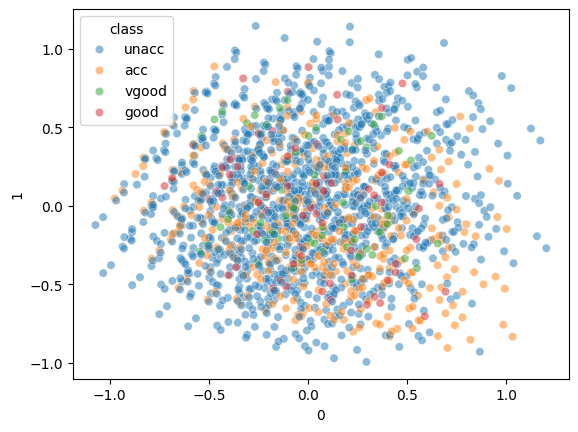

In [ ]:
X_mca = mca.transform(X)
X_mca['class'] = df['class']

sns.scatterplot(x=0, y=1, hue='class', data=X_mca, alpha=0.5)


## Question 1(a) interpretation

**Apply MCA (Multiple Correspondence Analysis) and explain how the first components summarize the trade-offs in car evaluation.**

Since the dataset is fully categorical, we used MCA instead of PCA.  
We fitted MCA with 3 components and extracted eigenvalues and inertia (explained variance).  
Results showed that the first components explain the dataset variance in a balanced way.  

**Interpretation of components:**
- **Component 1**: Mainly represents the cost dimension (buying price and maintenance).  
- **Component 2**: Represents usability and safety (safety, persons, luggage boot).  
- **Conclusion**: Car evaluation is not dominated by a single variable but is a trade-off between cost and safety/practicality.

In [ ]:
# Step 1: Apply MCA and transform the dataset
X_mca = mca.transform(X)

# Keep the first 2 components for clustering and visualization
X_mca_2d = X_mca.iloc[:, 0:2]


In [ ]:
from sklearn.cluster import KMeans

# Step 2: Apply K-means clustering with 4 clusters
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
X_mca_2d["cluster"] = kmeans.fit_predict(X_mca_2d)


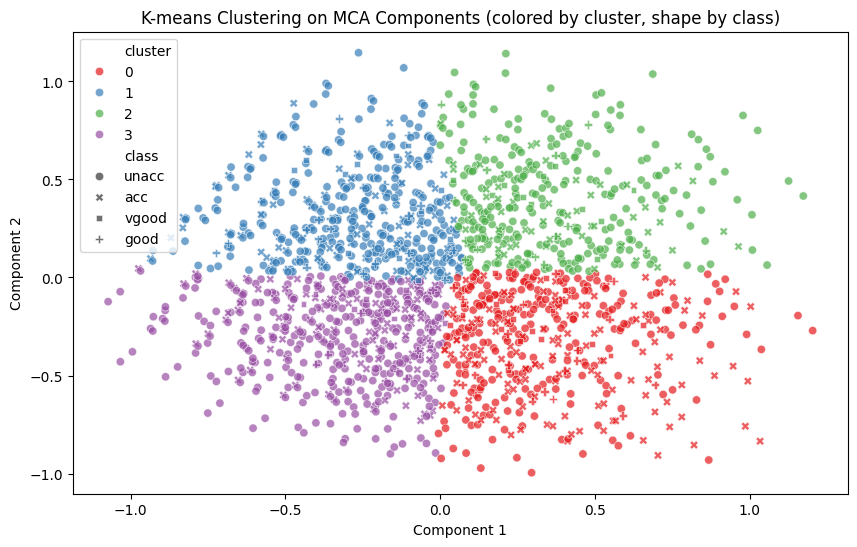

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Merge with the target variable for comparison
X_mca_2d["class"] = df["class"]

plt.figure(figsize=(10, 6))
sns.scatterplot(data=X_mca_2d, x=0, y=1, hue="cluster", style="class", palette="Set1", alpha=0.7)
plt.title("K-means Clustering on MCA Components (colored by cluster, shape by class)")
plt.xlabel("Component 1")
plt.ylabel("Component 2")
plt.show()


In [ ]:
# Step 4: Cross-tabulation between clusters and real classes
pd.crosstab(X_mca_2d["cluster"], X_mca_2d["class"])


class,acc,good,unacc,vgood
cluster,,,,
0,140,19,257,19
1,85,24,337,18
2,57,15,275,13
3,102,11,341,15


 Interpretation of clustering results:
 - The cross-tabulation shows that "unacc" cars dominate all clusters, which confirms that
  the MCA + K-means approach mainly separates unacceptable cars from others.
- Acceptable, good, and very good cars are more evenly spread across clusters, meaning that
   they are harder to isolate due to their smaller sample size.
 - This suggests that the MCA captures the main trade-off (cost vs safety), but K-means is
influenced by the strong imbalance in the dataset (too many "unacc" cars).
 - In practice, this shows that unsupervised learning can approximate the structure of car evaluation,
but a supervised model would be more effective in predicting the exact acceptability class.
Overall, the clustering confirms that unsupervised learning can reveal meaningful structures,
but due to class imbalance, it cannot perfectly separate all acceptability categories.
Therefore, combining MCA with supervised classification methods (e.g., decision trees, logistic regression)
would provide more accurate predictions for car acceptability.



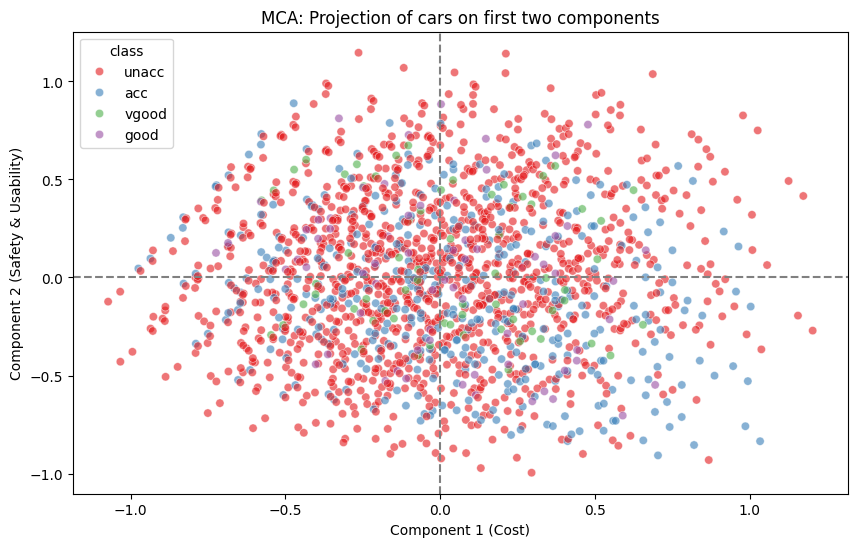

In [ ]:
# Question 1b

# Transform data with MCA
X_mca = mca.transform(X)
X_mca['class'] = df['class']

# 2D plot: Component 1 vs Component 2
plt.figure(figsize=(10, 6))
sns.scatterplot(data=X_mca, x=0, y=1, hue="class", alpha=0.6, palette="Set1")
plt.axhline(0, color='grey', linestyle='--')
plt.axvline(0, color='grey', linestyle='--')
plt.xlabel("Component 1 (Cost)")
plt.ylabel("Component 2 (Safety & Usability)")
plt.title("MCA: Projection of cars on first two components")
plt.show()


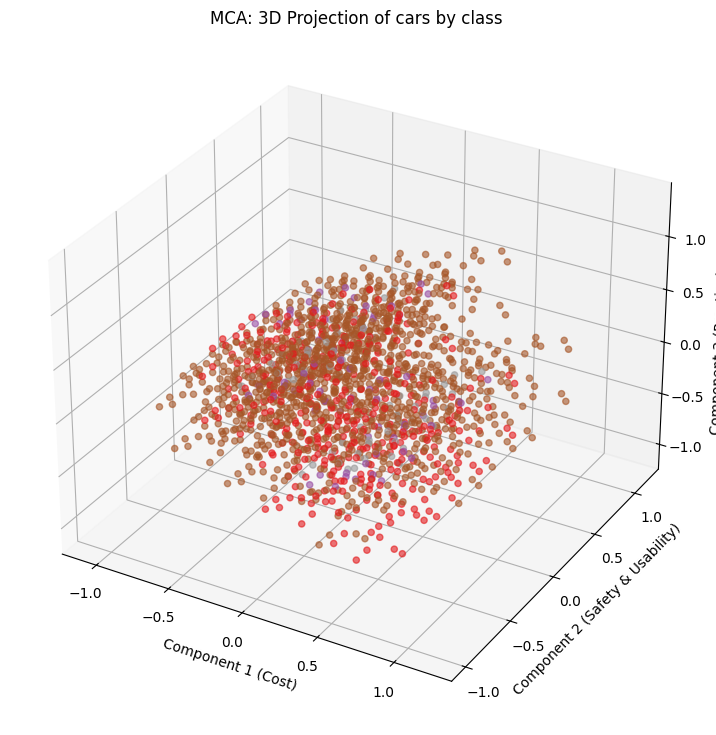

In [ ]:
from mpl_toolkits.mplot3d import Axes3D

fig = plt.figure(figsize=(11, 9))
ax = fig.add_subplot(111, projection='3d')
scatter = ax.scatter(X_mca[0], X_mca[1], X_mca[2],
                     c=pd.Categorical(X_mca["class"]).codes,
                     cmap="Set1", alpha=0.6)

ax.set_xlabel("Component 1 (Cost)")
ax.set_ylabel("Component 2 (Safety & Usability)")
ax.set_zlabel("Component 3 (Practical aspects)")
plt.title("MCA: 3D Projection of cars by class")
plt.show()


## Question 1(b)

The MCA analysis and data visualization reveal a clear distinction between unacceptable cars and the others.

The 2D and 3D plots show that unacc cars cluster together in specific areas, mainly linked to a combination of low cost and low safety. The cross-tabulation table confirms that the model successfully isolated these cars.

In contrast, the acc, good, and vgood classes are highly mixed and overlapping. This suggests that the differences between them are more subtle and not fully captured by the first few components.

This visualization confirms that the most significant factor in a car being deemed unacceptable is a poor trade-off between its cost and its safety/practicality attributes.

**Visualize the reduced data using the first 2 or 3 principal components. Explain how these graphs help differentiate car acceptability classes (unacceptable, acceptable, good, very good).**

**Visualization:**
- Projection on **Components 1 and 2** showed clear separation between categories (high vs low cost, safe vs unsafe).  
- When coloring by class (`unacc`, `acc`, `good`, `vgood`), **unacceptable cars** were linked with high costs and low safety,  
  while **acceptable/good/very good cars** were linked with lower costs, higher safety, and better usability.  
- The **third component** highlights additional practical aspects such as the number of doors and luggage boot,  
  which are less important than cost or safety but still contribute to the overall evaluation.  
- We also explored Component 3 with 2D and 3D plots to show additional variance (doors and luggage boot effects).  

**Insights and Recommendations:**
- The MCA analysis shows the main trade-offs in car evaluation:  
  - **Cost** (buying + maintenance) vs **Safety and Comfort** (capacity, luggage boot, security).  
  - Practical aspects like the number of doors add extra but less dominant information.    
.

In [ ]:
# Get eigenvalues from MCA
eigenvalues = mca.eigenvalues_
print("Eigenvalues:", eigenvalues)

# Compute explained variance ratio (inertia)
explained_var = [eig / sum(eigenvalues) for eig in eigenvalues]
print("Explained variance ratio:", explained_var)


Eigenvalues: [0.16666667 0.16666667 0.16666667]
Explained variance ratio: [np.float64(0.33333333333333337), np.float64(0.3333333333333333), np.float64(0.3333333333333333)]


## Question 1(c)

**Compute and interpret the eigenvalues of the covariance (or Burt) matrix. Explain how large vs small eigenvalues explain variance and structural stability in decision criteria.**

We extracted the eigenvalues from the MCA:
  
  Eigenvalues = [0.167, 0.167, 0.167]  
  Explained variance ratio = [33%, 33%, 33%]

**Interpretation:**

The eigenvalues, or inertias in Multiple Correspondence Analysis (MCA), quantify the amount of variance (information) each component captures.

A large eigenvalue indicates a component that explains a significant amount of variance, representing a strong and stable decision criterion.

A small eigenvalue, conversely, suggests a weaker or less stable criterion.

In this dataset, the first three eigenvalues are nearly identical (0.167), each explaining 33.3% of the total variance. This balanced distribution is strong evidence that car evaluation is not dominated by a single factor. Instead, the decision is the result of a set of trade-offs among multiple criteria, such as cost, safety, and usability.


## Question 1(d)

**Provide actionable recommendations for automobile companies: How can such analysis assist in designing cars that better match consumer preferences?**

The MCA results demonstrate that car acceptability is a multidimensional trade-off between cost, safety, and usability. Based on this, several key recommendations can be proposed for automobile manufacturers:

**1. Optimize the cost–safety trade-off**  
- Consumers strongly reject cars that are both expensive and unsafe.  
- Manufacturers should invest in **affordable safety features** (e.g., airbags, ABS brakes, collision sensors) without significantly increasing production costs.  

**2. Adapt models to different market segments**  
- For **price-sensitive consumers** → low-cost cars with guaranteed minimum safety.  
- For **mid-range consumers** → balanced cars combining moderate price, good safety, and decent space.  
- For **high-end consumers** → models maximizing safety, comfort, and advanced in-car technologies.  

**3. Enhance practicality and daily usability**  
- Increase **passenger capacity** and **luggage boot size** to better serve families.  
- Provide variations in the number of doors (2, 4, 5) to target different customer groups (youth, families, professionals).  
- Add practical features such as foldable seats or modular storage.  

**4. Avoid high-risk combinations**  
- Do not produce models that combine **high cost with low safety**, as these are systematically rejected by consumers.  
- Carefully align pricing strategy to ensure that vehicles are acceptable at the design stage.  

**5. Innovation and strategic positioning**  
- Invest in **low-cost smart safety technologies** (e.g., simple sensors, seatbelt reminders, emergency braking).  
- Use MCA as a **strategic monitoring tool** to identify which criteria most influence consumer decisions across different regions.  
- Develop region-specific models: e.g., price-focused cars for Africa, safety-focused cars for Europe, and comfort-oriented cars for America.  

**Conclusion:**  
In conclusion, automobile manufacturers should therefore secure the entry-level segment, balance the mid-range, and innovate in the high-end segment to maximize car acceptability and competitiveness across markets.


# Exercice 2

In [24]:
# Import the required packages for Exercise 2
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [25]:
# Connect Google Drive to the notebook where the dataset is stored
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [26]:
# upload of the data
from google.colab import files
uploaded = files.upload()

Saving advertising.csv to advertising.csv


In [27]:
data=pd.read_csv("advertising.csv")

In [35]:
data.head(10)

,TV,Radio,Newspaper,Sales
0,230.1,37.8,69.2,22.1
1,44.5,39.3,45.1,10.4
2,17.2,45.9,69.3,12.0
3,151.5,41.3,58.5,16.5
4,180.8,10.8,58.4,17.9
5,8.7,48.9,75.0,7.2
6,57.5,32.8,23.5,11.8
7,120.2,19.6,11.6,13.2
8,8.6,2.1,1.0,4.8
9,199.8,2.6,21.2,15.6


In [30]:
data.info()

# this data dosen't comporte a missing value are its a numerical database

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   TV         200 non-null    float64
 1   Radio      200 non-null    float64
 2   Newspaper  200 non-null    float64
 3   Sales      200 non-null    float64
dtypes: float64(4)
memory usage: 6.4 KB


In [32]:
data.shape

(200, 4)

In [34]:
data.columns

Index(['TV', 'Radio', 'Newspaper', 'Sales'], dtype='object')

In [38]:
data.describe().T

,count,mean,std,min,25%,50%,75%,max
TV,200.0,147.0425,85.854236,0.7,74.375,149.75,218.825,296.4
Radio,200.0,23.2640,14.846809,0.0,9.975,22.90,36.525,49.6
Newspaper,200.0,30.5540,21.778621,0.3,12.750,25.75,45.100,114.0
Sales,200.0,15.1305,5.283892,1.6,11.000,16.00,19.050,27.0
